In [1]:
import os, copy
import glob

import numpy as np
import scipy.optimize as so
import pandas as pd
import xarray as xr
import rioxarray as rxr

import netCDF4
import h5py
from osgeo import gdal

%matplotlib inline  
import matplotlib as mpl
import matplotlib.pyplot as plt
import colorcet as cc

from hgrs import auxdata, driver
import hgrs

opj = os.path.join
hgrs.__version__

'1.0.5'

## Load metadata through the prismapy package

In [2]:

solar_irr = hgrs.SolarIrradiance()


## Solar irradiance

In [3]:
tsis = xr.open_dataset('/DATA/git/satellite_app/hgrs/data/aux/hybrid_reference_spectrum_p1nm_resolution_c2022-11-30_with_unc.nc')
tsis = tsis.set_index(wavelength='Vacuum Wavelength').rename({'wavelength':'wl'})#set_coords('Vacuum Wavelength')
# convert
tsis['SSI']=tsis.SSI*1000#.plot(lw=0.5)
tsis.SSI.attrs['units']='mW m-2 nm-1'
tsis.SSI.attrs['long_name']='Solar Spectral Irradiance Reference Spectrum (mW m-2 nm-1)'

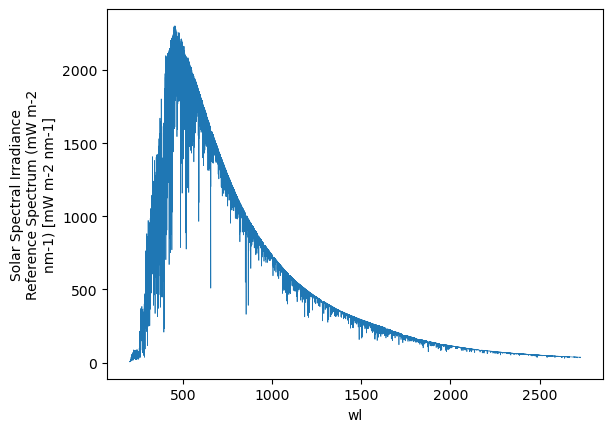

In [4]:

tsis.SSI.plot(lw=0.5)

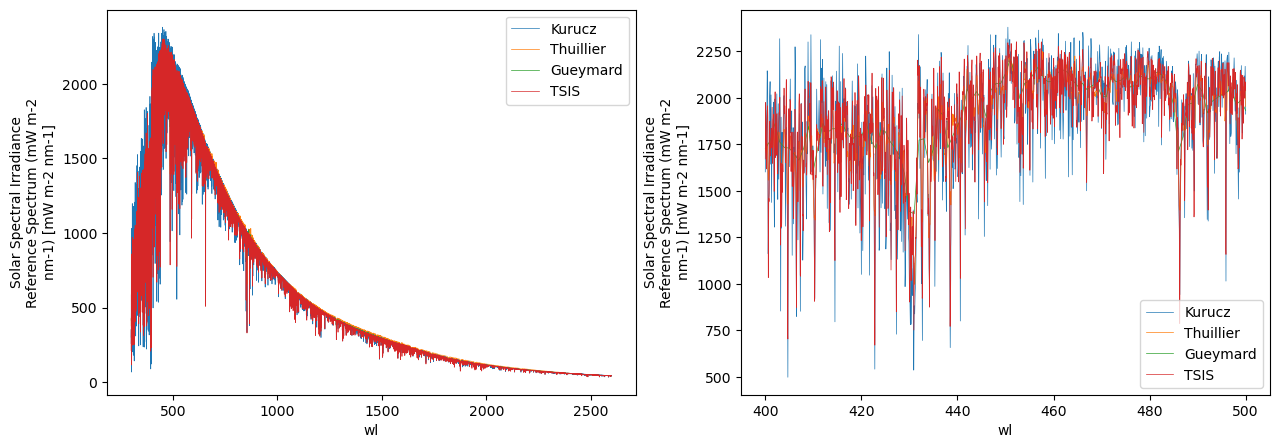

In [4]:
fig,axs = plt.subplots(1,2,figsize=(15,5))

solar_irr.kurucz.plot(lw=0.5,ax=axs[0],label='Kurucz')
solar_irr.thuillier.plot(lw=0.5,ax=axs[0],label='Thuillier')
solar_irr.gueymard.plot(lw=0.5,ax=axs[0],label='Gueymard')
solar_irr.tsis.plot(lw=0.5,ax=axs[0],label='TSIS')

axs[0].legend()

solar_irr.kurucz.sel(wl=slice(400,500)).plot(lw=0.5,ax=axs[1],label='Kurucz')
solar_irr.thuillier.sel(wl=slice(400,500)).plot(lw=0.5,ax=axs[1],label='Thuillier')
solar_irr.gueymard.sel(wl=slice(400,500)).plot(lw=0.5,ax=axs[1],label='Gueymard')
solar_irr.tsis.sel(wl=slice(400,500)).plot(lw=0.5,ax=axs[1],label='TSIS')
axs[1].legend()

In [3]:
fwhm = xr.open_dataarray(opj(hgrs.__path__[0],'..','data','aux','prisma_fwhm.nc'))
fwhm.load()

<xarray.DataArray 'fwhm' (wl: 232)>
array([11.352248 , 10.377187 ,  9.750846 ,  9.332583 ,  9.22605  ,
        9.195631 ,  9.123976 ,  9.059169 ,  8.920167 ,  8.914632 ,
        8.908112 ,  9.007447 ,  9.206349 ,  9.2927   ,  9.366909 ,
        9.507074 ,  9.641453 ,  9.669557 ,  9.795126 , 10.017526 ,
       10.059797 , 10.173916 , 10.31268  , 10.395864 , 10.554132 ,
       10.826656 , 10.924109 , 11.071507 , 11.219973 , 11.142748 ,
       11.548293 , 11.6332   , 11.71825  , 11.8385105, 11.979173 ,
       12.036037 , 11.982176 , 12.482482 , 12.349199 , 12.419001 ,
       12.564529 , 12.627702 , 12.805029 , 12.744262 , 12.7641325,
       12.854497 , 12.948172 , 12.956257 , 12.987681 , 13.008858 ,
       13.088384 , 13.1459   , 13.171485 , 13.043188 , 13.106065 ,
       13.110408 , 13.066294 , 12.880766 , 12.754054 , 10.941308 ,
       13.277605 , 11.012961 , 13.463784 , 12.200682 , 12.150509 ,
       12.132591 , 12.284694 , 12.670556 , 12.45165  , 12.974532 ,
       12.956487 , 13.562425 , 13.63141  , 13.820859 , 14.045175 ,
       14.162271 , 14.285313 , 14.238944 , 14.608084 , 14.186169 ,
       14.544166 , 14.336425 , 14.474231 , 14.861722 , 14.459894 ,
       14.564523 , 14.469394 , 14.744387 , 14.600766 , 14.889258 ,
       14.525333 , 14.982994 , 15.112422 , 14.747745 , 14.70724  ,
       14.624428 , 14.654754 , 14.736323 , 14.81003  , 14.649706 ,
...
       13.020383 , 12.810986 , 12.835281 , 12.975467 , 13.077787 ,
       12.7134075, 12.474877 , 12.595072 , 12.728243 , 12.5481415,
       12.371736 , 13.079377 , 12.488643 , 12.584005 , 12.621728 ,
       12.361816 , 11.465725 , 12.5673685, 11.774035 , 11.6357765,
       12.725526 , 11.897087 , 12.1846285, 11.810174 , 11.953557 ,
       11.727077 , 11.549416 , 11.735335 , 11.573802 , 11.815879 ,
       11.40911  , 11.539112 , 11.387559 , 11.433579 , 11.25816  ,
       11.423655 , 11.128364 , 11.170842 , 11.098422 , 11.263509 ,
       11.092496 , 11.204863 , 11.016215 , 11.008936 , 10.974517 ,
       10.960912 , 10.839494 , 10.904037 , 10.710894 , 10.727883 ,
       10.979726 , 10.405291 , 10.818141 , 10.42951  , 10.534756 ,
       10.707573 , 10.253851 , 10.568967 , 10.31996  , 10.489971 ,
       10.470257 , 10.248984 , 10.3534155, 10.397237 , 10.105657 ,
       10.3918495,  9.950322 , 10.220057 , 10.140627 ,  9.81789  ,
       10.38666  ,  9.861345 ,  9.8734255, 10.234986 ,  9.733903 ,
        9.741749 , 10.133815 ,  9.642411 ,  9.70783  ,  9.828164 ,
        9.870838 ,  9.448557 ,  9.842932 ,  9.833664 ,  9.114236 ,
        9.907518 ,  9.633436 ,  9.6099205,  8.92421  ,  9.60746  ,
        9.568544 ,  9.059477 ,  9.328547 ,  9.811145 ,  9.122717 ,
        9.218007 ,  9.728999 ], dtype=float32)
Coordinates:
  * wl       (wl) float32 407.0 415.8 423.8 ... 2.484e+03 2.49e+03 2.497e+03

In [6]:
wl_common = solar_irr.kurucz.wl
#tsis_irr = tsis.SSI.interp(wl=wl_common)

In [8]:
F0= solar_irr.gueymard
F0 = solar_irr.kurucz
F0_gueymard=solar_irr.convolve(solar_irr.gueymard, fwhm)
F0_kurucz = solar_irr.convolve(solar_irr.kurucz, fwhm)
F0_thuillier = solar_irr.convolve(solar_irr.thuillier, fwhm)
F0_tsis = solar_irr.convolve(solar_irr.tsis, fwhm)

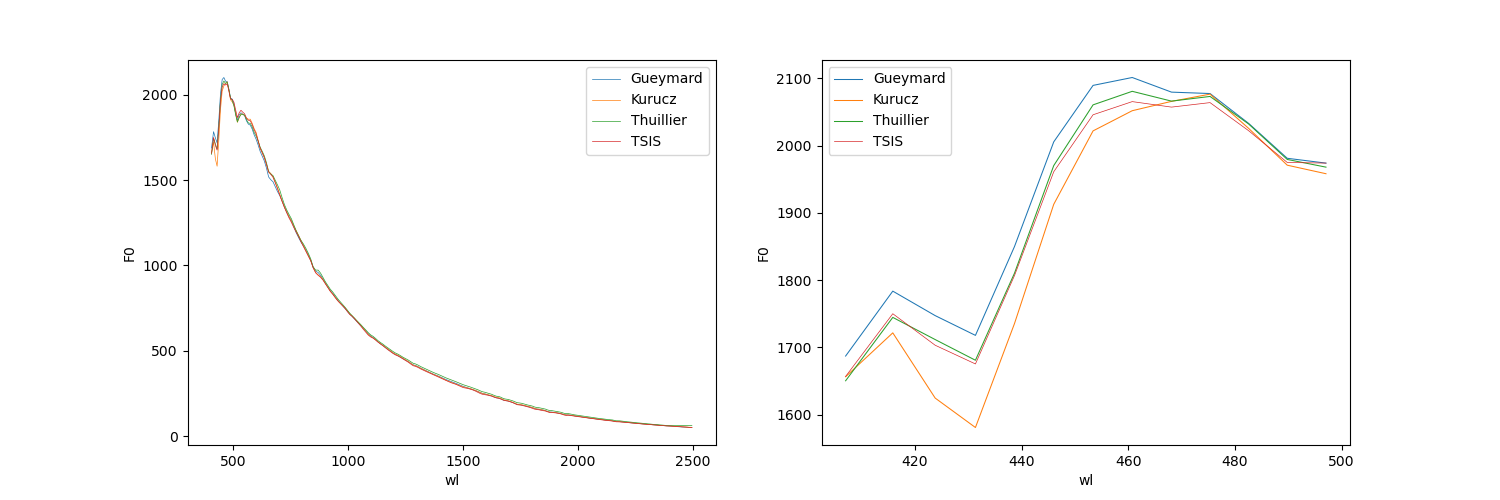

In [9]:
%matplotlib widget
fig,axs = plt.subplots(1,2,figsize=(15,5))
F0_gueymard.plot(lw=0.5,ax=axs[0],label='Gueymard')
F0_kurucz.plot(lw=0.5,ax=axs[0],label='Kurucz')
F0_thuillier.plot(lw=0.5,ax=axs[0],label='Thuillier')
F0_tsis.plot(lw=0.5,ax=axs[0],label='TSIS')
axs[0].legend()
F0_gueymard.sel(wl=slice(400,500)).plot(lw=0.75,ax=axs[1],label='Gueymard')
F0_kurucz.sel(wl=slice(400,500)).plot(lw=0.75,ax=axs[1],label='Kurucz')
F0_thuillier.sel(wl=slice(400,500)).plot(lw=0.75,ax=axs[1],label='Thuillier')
F0_tsis.sel(wl=slice(400,500)).plot(lw=0.5,ax=axs[1],label='TSIS')
axs[1].legend()

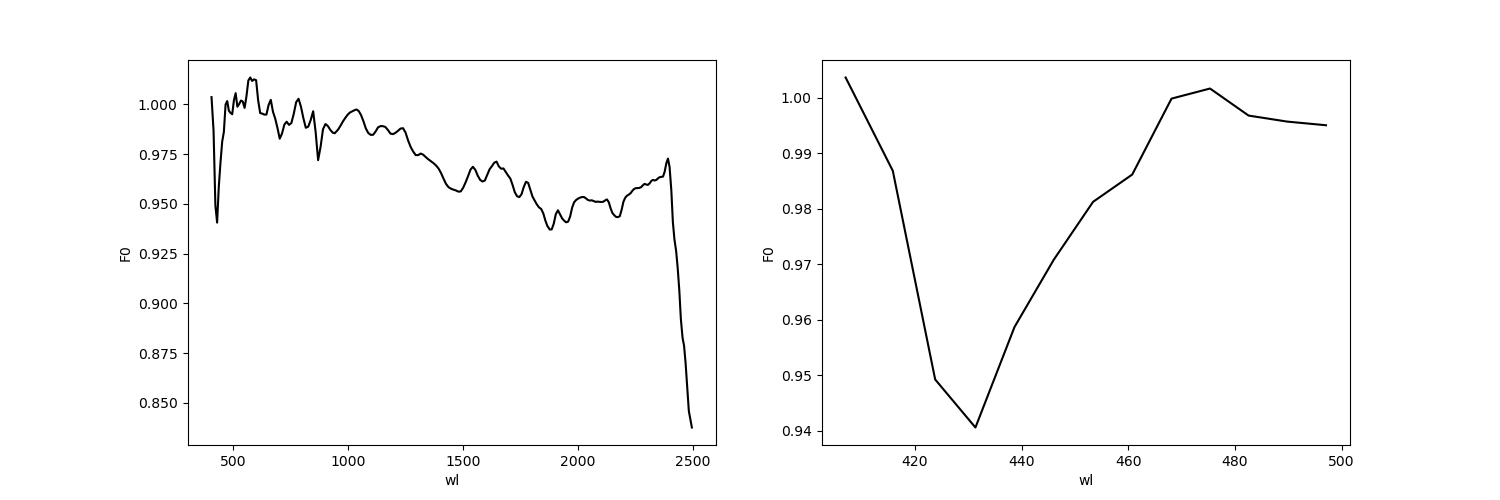

In [10]:
ratio_kurucz_thuillier=(F0_kurucz/F0_thuillier)#**5

fig,axs = plt.subplots(1,2,figsize=(15,5))
ratio_kurucz_thuillier.plot(color='black',ax=axs[0])
ratio_kurucz_thuillier.sel(wl=slice(400,500)).plot(color='black',ax=axs[1])
#(ratio_kurucz_thuillier).to_netcdf('/home/harmel/Desktop/ratio_kurucz_thuillier.nc')

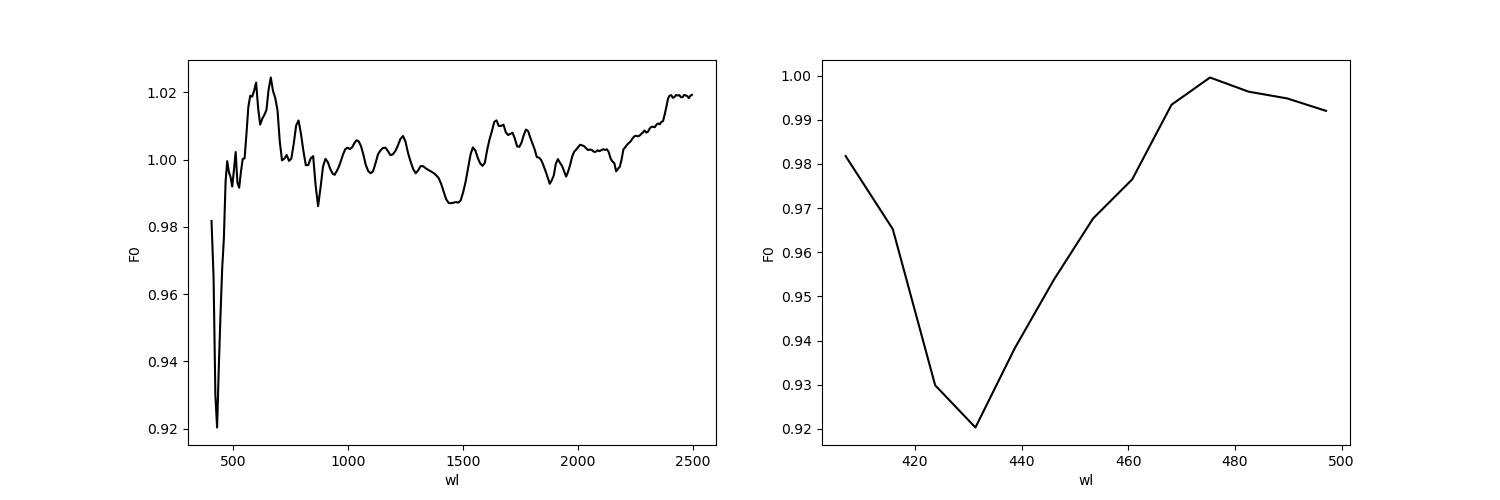

In [11]:
ratio_kurucz_gueymard=(F0_kurucz/F0_gueymard) #**5

fig,axs = plt.subplots(1,2,figsize=(15,5))
ratio_kurucz_gueymard.plot(color='black',ax=axs[0])
ratio_kurucz_gueymard.sel(wl=slice(400,500)).plot(color='black',ax=axs[1])
ratio_kurucz_gueymard.to_netcdf('/home/harmel/Desktop/ratio_kurucz_gueymard.nc')

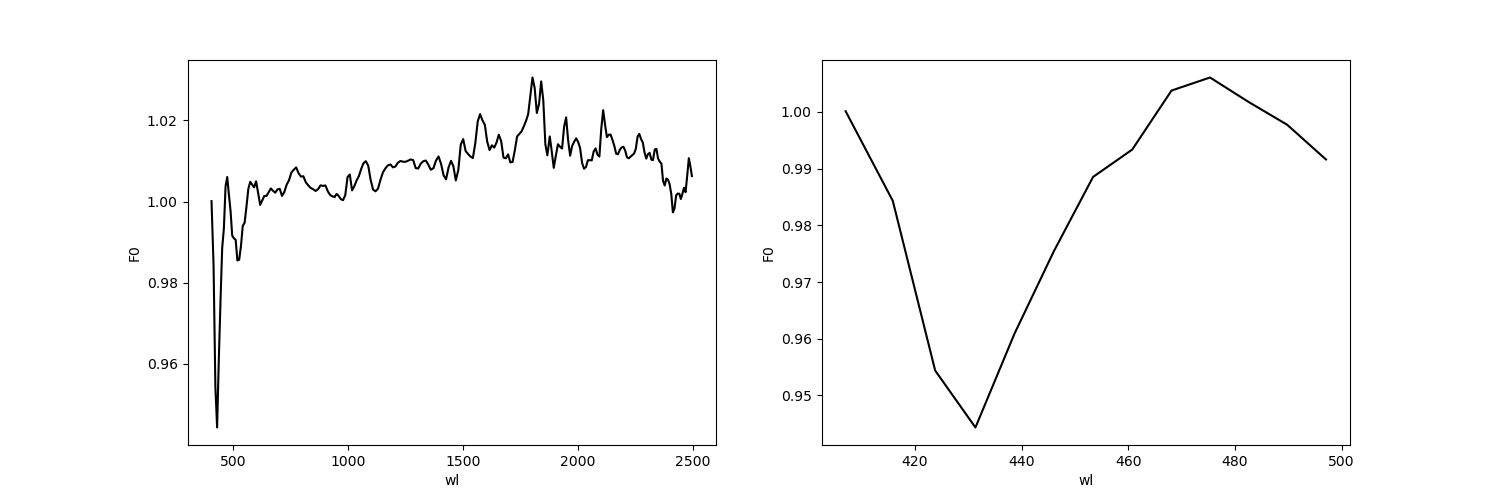

In [13]:
ratio_kurucz_tsis=(F0_kurucz/F0_tsis) #**5

fig,axs = plt.subplots(1,2,figsize=(15,5))
ratio_kurucz_tsis.plot(color='black',ax=axs[0])
ratio_kurucz_tsis.sel(wl=slice(400,500)).plot(color='black',ax=axs[1])

## Sunglint spectral variation (i.e., of the surface BRDF) 

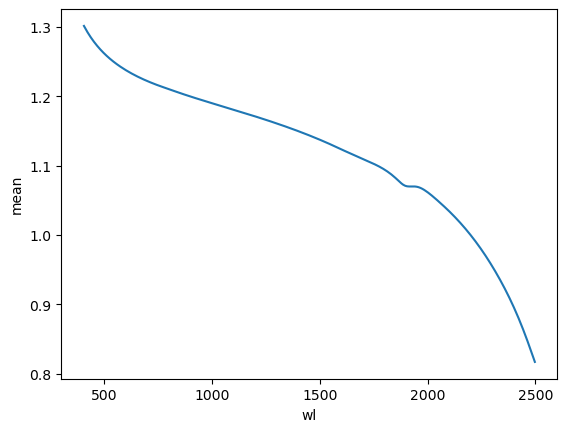

In [17]:

sunglintBRDF =  sunglint_eps['mean'] / sunglint_eps['mean'].sel(wl=wlref,method='nearest')
sunglintBRDF.plot()


## Optical thicknesses of aerosol and non-absorbing molecules (i.e., Rayleigh)

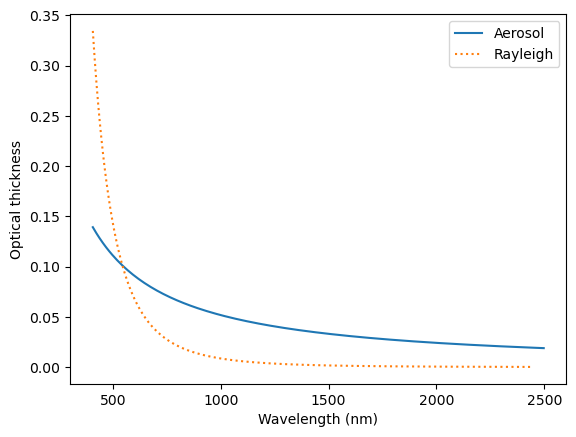

In [20]:
aot550=0.1
ang_exp = 1.1

def aot_angstrom(wl, aotref, ang_exp,wlref=550):
    '''function for spectral variation of AOT'''
    
    return (wl/wlref)**-ang_exp * aotref

aot=aot_angstrom(wl,aot550,ang_exp)

fig, axs = plt.subplots()
aot.plot(ax=axs,label='Aerosol')
auxdata.rot.plot(ls=':',label='Rayleigh',ax=axs)
axs.set_xlabel('Wavelength (nm)')
axs.set_ylabel('Optical thickness')
plt.legend()

## Atmospheric transmittance including absorbing gases

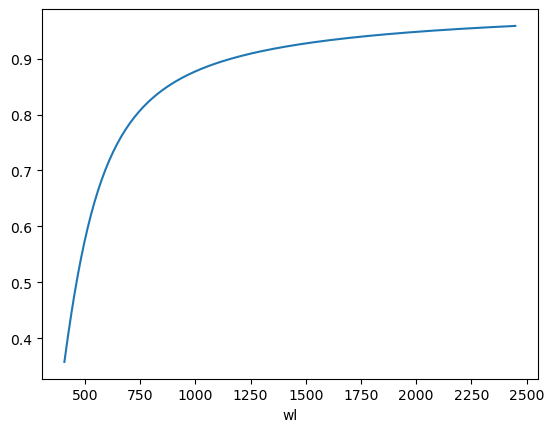

In [23]:
def transmittance_dir(aot,sza=30,vza=10,rot=0):
    air_mass = 1/np.cos(np.radians(sza)) + 1/np.cos(np.radians(vza))
    return np.exp(-(rot+aot)*air_mass)
                
Tdir = transmittance_dir(aot,rot=auxdata.rot)
Tdir.plot()

In [153]:
import holoviews as hv
import hvplot.xarray

file = '/media/harmel/vol1/Dropbox/work/VRTC/libRadtran-2.0.4/reptran_2017_all/data/correlated_k/reptran/reptran_solar_medium.lookup.H2O.cdf'
h2o = xr.open_dataset(file).swap_dims({'nwvl':'wvl','n_pressure':'pressure','n_t_pert':'t_pert' ,'n_vmrs':'vmrs' }).rename({'wvl':'wl'}).squeeze()#,decode_cf=False)

file = '/media/harmel/vol1/Dropbox/work/VRTC/libRadtran-2.0.4/reptran_2017_all/data/correlated_k/reptran/reptran_solar_fine.lookup.N2O.cdf'
n2o = xr.open_dataset(file).swap_dims({'nwvl':'wvl','n_pressure':'pressure','n_t_pert':'t_pert' ,'n_vmrs':'vmrs' }).rename({'wvl':'wl'}).squeeze()

file = '/media/harmel/vol1/Dropbox/work/VRTC/libRadtran-2.0.4/reptran_2017_all/data/correlated_k/reptran/reptran_solar_fine.lookup.O3.cdf'
o3 = xr.open_dataset(file).swap_dims({'nwvl':'wvl','n_pressure':'pressure','n_t_pert':'t_pert' ,'n_vmrs':'vmrs' }).rename({'wvl':'wl'}).squeeze()

file = '/media/harmel/vol1/Dropbox/work/VRTC/libRadtran-2.0.4/reptran_2017_all/data/correlated_k/reptran/reptran_solar_fine.lookup.O2.cdf'
o2 = xr.open_dataset(file).swap_dims({'nwvl':'wvl','n_pressure':'pressure','n_t_pert':'t_pert' ,'n_vmrs':'vmrs' }).rename({'wvl':'wl'}).squeeze()


file = '/media/harmel/vol1/Dropbox/work/VRTC/libRadtran-2.0.4/reptran_2017_all/data/correlated_k/reptran/reptran_solar_fine.lookup.N2.cdf'
n2 = xr.open_dataset(file).swap_dims({'nwvl':'wvl','n_pressure':'pressure','n_t_pert':'t_pert' ,'n_vmrs':'vmrs' }).rename({'wvl':'wl'}).squeeze()



In [161]:
file = '/media/harmel/vol1/Dropbox/work/VRTC/libRadtran-2.0.4/data/correlated_k/reptran/reptran_solar_coarse.lookup.O3.cdf'
o3 = xr.open_dataset(file)

In [162]:
o3.wvl.values

array([2447.89015861, 2448.73489783, 2450.12073205, 2450.75163069,
       2452.27513728, 2454.75487948, 2456.45946851, 2460.02209491,
       2462.02714215, 2464.46081438, 2466.77751735, 2469.51042766,
       2470.41595842, 2472.83565665, 2475.20900967, 2476.07782474,
       2479.3695136 , 2480.25151177, 2481.58595669, 2483.07607106,
       2484.1871127 , 2486.00498454, 2486.79372741, 2488.827175  ,
       2490.1967207 , 2491.16406227, 2491.93019175, 2494.54271166,
       2495.90816717, 2498.91431312, 2499.14865949, 2501.01979795,
       2503.22288348, 2504.29450405, 2508.27011371, 2508.83683918,
       2508.94181645, 2509.82397245, 2511.74270098, 2514.63948307,
       2517.23645408, 2517.39497949, 2518.20905769, 2520.01353444,
       2521.56607553, 2525.36274178, 2526.16069652, 2526.43743855,
       2528.59491015, 2531.3009442 , 2535.73274114, 2536.60164759,
       2537.4604115 , 2539.8357715 , 2540.82592067, 2542.01619688,
       2543.16983529, 2545.09669513, 2550.1408292 , 2551.01963

In [152]:
o3.xsec.hvplot.line(x='wl',line_width=0.5,framewise=False)

:DynamicMap   [t_pert,pressure]
   :Curve   [wl]   (xsec)

In [128]:
h2o.hvplot.line(x='wl',line_width=0.5,framewise=False)

:DynamicMap   [t_pert,vmrs,pressure]
   :Curve   [wl]   (xsec)

In [112]:
h2o = h2o.swap_dims({'nwvl':'wvl','n_pressure':'pressure','n_t_pert':'t_pert' ,'n_vmrs':'vmrs' }).rename({'wvl':'wl'})#.set_coords(['wl','pressure','vmrs','t_pert']).xsec.copy()
h2o = h2o.rename({'wvl':'wl'})
h2o = h2o#.where(h2o_.wl <=1250,drop=True)

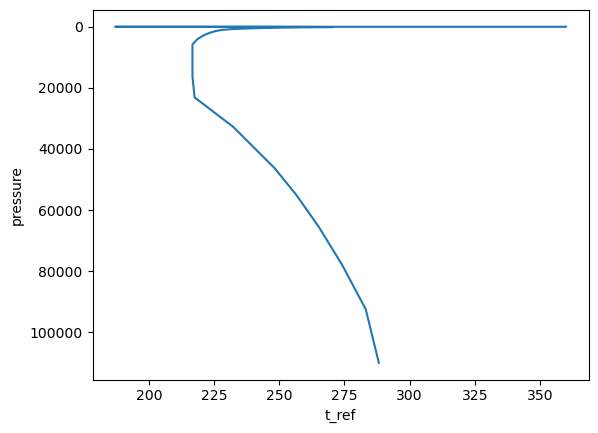

In [113]:
h2o.t_ref.plot(y='pressure',yincrease=False)

(800.0, 1000.0)

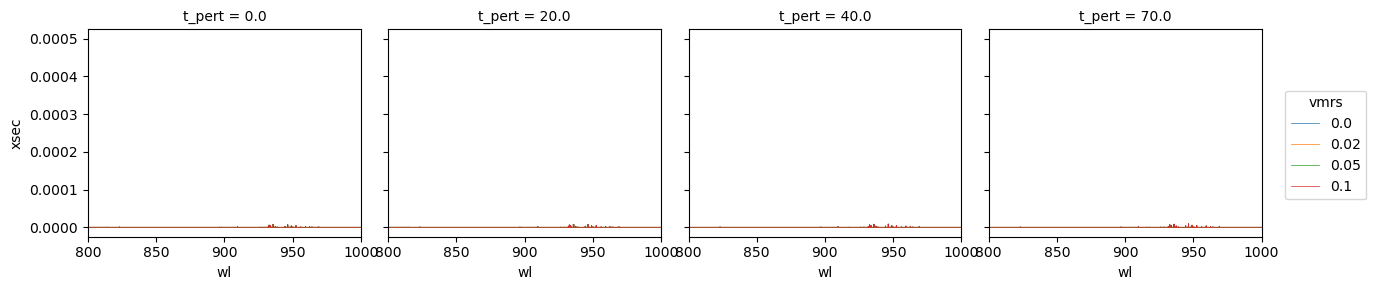

In [117]:
%matplotlib inline
#h2o = h2o.xsec.where(h2o.wl <=2500,drop=True)
h2o..isel(pressure=-1,t_pert=slice(-5,-1)).plot(x='wl',col='t_pert',hue='vmrs',lw=0.5)
plt.xlim([800,1000])

In [44]:
sunglint_corr = Tdir * sunglintBRDF
Rcorr = masked.Rtoa - sunglint_corr * masked.Rtoa.sel(wl=wlref,method='nearest')

NameError: name 'Tdir' is not defined

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


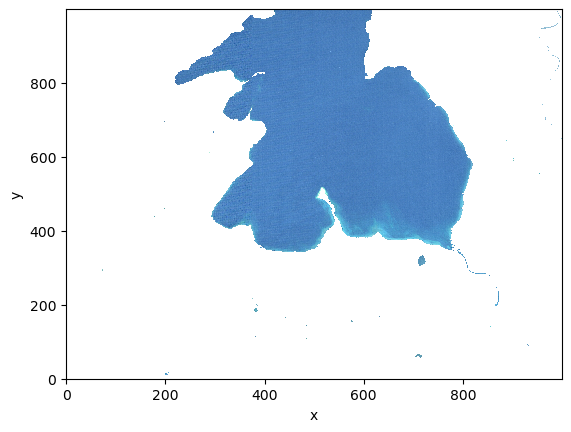

In [27]:
(Rcorr[:, ::coarsening, ::coarsening].isel(wl=[30,20,10])*brightness_factor).plot.imshow(rgb='wl')#, subplot_kws=dict(projection= l1c.proj))